In [ ]:
# Task 1

## Step 0 - Import functionalities
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1 - Load the dataset
cancer = load_breast_cancer()

# Features (30 measurements like radius, texture, area...)
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Target: 0 = malignant (cancer), 1 = benign (healthy)
y = pd.Series(cancer.target)

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())

# Step 2 - Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3 - Train the Logistic Regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Step 4 - Make predictions
y_pred = model.predict(X_test)

# Step 5 - Evaluate the model
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Step 6 - Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Breast Cancer (Logistic Regression)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("breast_cancer_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# task 2

=== BASELINE (single train/test split) ===
Accuracy: 0.9561
Precision: 0.9459
Recall: 0.9859
F1-Score: 0.9655

=== CROSS-VALIDATION (5-fold) ===
Accuracy  per fold: [0.9649 0.9211 0.9649 0.9474 0.9735]  → Mean: 0.9543 ± 0.0187
Precision per fold: [1.     0.9079 0.9474 0.9714 0.9595] → Mean: 0.9572 ± 0.0302
Recall    per fold: [0.9437 0.9718 1.     0.9444 1.    ]    → Mean: 0.9720 ± 0.0250
F1-Score  per fold: [0.971  0.9388 0.973  0.9577 0.9793]        → Mean: 0.9640 ± 0.0144


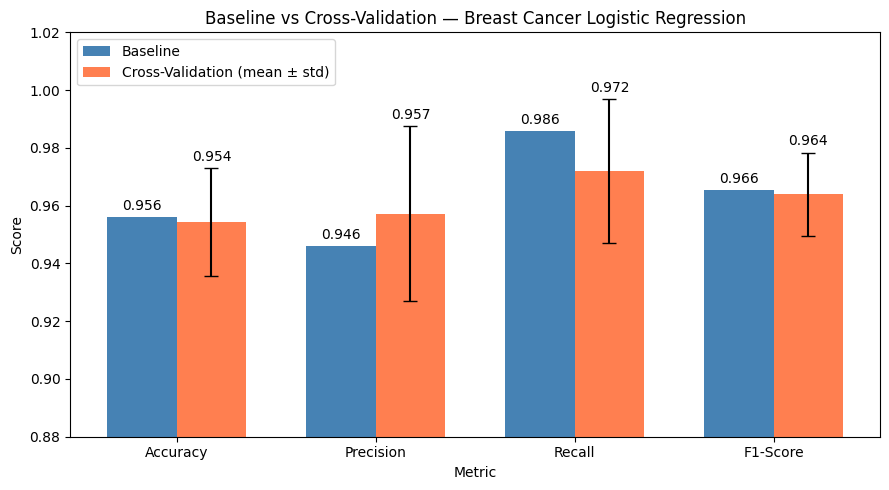

In [3]:
# ============================================================
# Task 2 - Cross-Validation vs Baseline
# ============================================================

# Step 0 - Import functionalities
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# Step 1 - Load dataset (same as Task 1)
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# -------------------------------------------------------
# BASELINE (from Task 1) - single train/test split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_model = LogisticRegression(max_iter=10000)
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

baseline_scores = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1-Score":  f1_score(y_test, y_pred),
}

print("=== BASELINE (single train/test split) ===")
for metric, value in baseline_scores.items():
    print(f"{metric}: {value:.4f}")

# -------------------------------------------------------
# CROSS-VALIDATION - 5-fold stratified CV
# -------------------------------------------------------
# StratifiedKFold keeps the class ratio balanced in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = LogisticRegression(max_iter=10000)

# Run CV for each metric separately
cv_accuracy  = cross_val_score(cv_model, X, y, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(cv_model, X, y, cv=cv, scoring='precision')
cv_recall    = cross_val_score(cv_model, X, y, cv=cv, scoring='recall')
cv_f1        = cross_val_score(cv_model, X, y, cv=cv, scoring='f1')

print("\n=== CROSS-VALIDATION (5-fold) ===")
print(f"Accuracy  per fold: {cv_accuracy.round(4)}  → Mean: {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"Precision per fold: {cv_precision.round(4)} → Mean: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"Recall    per fold: {cv_recall.round(4)}    → Mean: {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"F1-Score  per fold: {cv_f1.round(4)}        → Mean: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# -------------------------------------------------------
# VISUAL COMPARISON - Baseline vs CV
# -------------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

baseline_values = [baseline_scores[m] for m in metrics]
cv_values       = [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), cv_f1.mean()]
cv_errors       = [cv_accuracy.std(),  cv_precision.std(),  cv_recall.std(),  cv_f1.std()]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', color='steelblue')
bars2 = ax.bar(x + width/2, cv_values, width, yerr=cv_errors, capsize=5,
               label='Cross-Validation (mean ± std)', color='coral')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Baseline vs Cross-Validation — Breast Cancer Logistic Regression')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.88, 1.02)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig("cv_vs_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Task 3

=== LOGISTIC REGRESSION ===
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1-Score: 0.9790

Best K found: 7 (F1 = 0.9727)


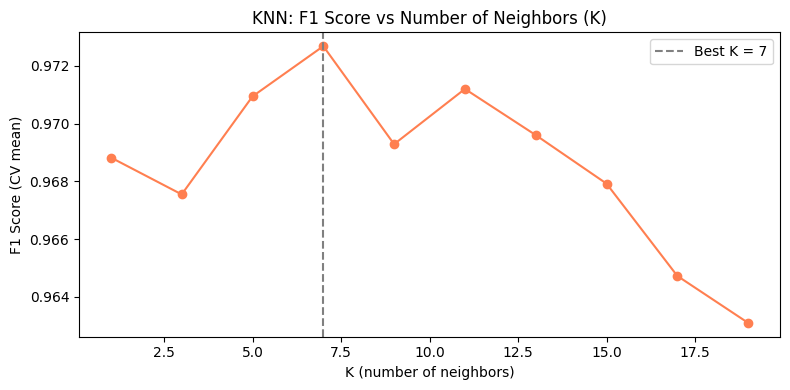


=== KNN (K=7) ===
Accuracy: 0.9474
Precision: 0.9577
Recall: 0.9577
F1-Score: 0.9577


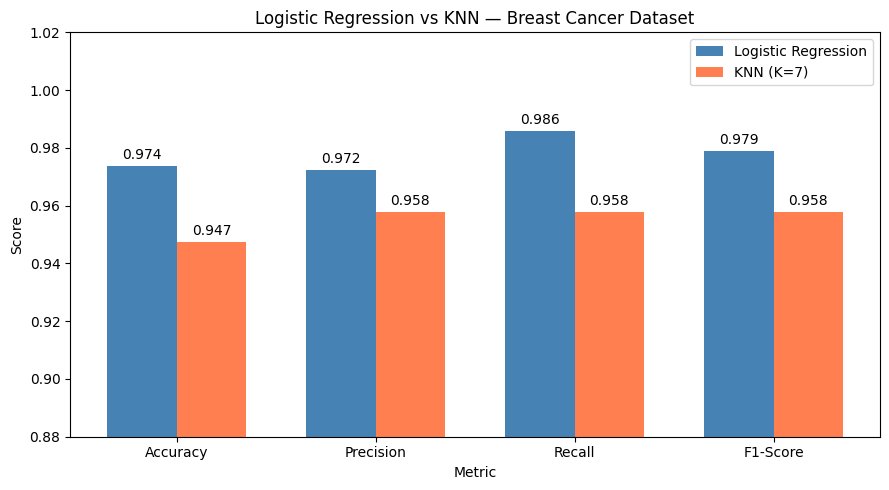

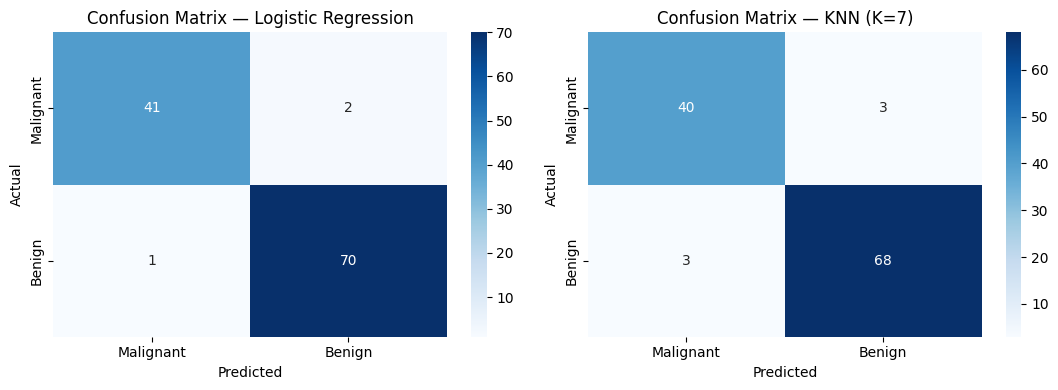

In [4]:
# ============================================================
# Task 3 - K-Nearest Neighbors vs Logistic Regression
# ============================================================

# Step 0 - Import functionalities
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1 - Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Step 2 - Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------------
# IMPORTANT: Scale features for KNN
# KNN uses distances between points, so larger-scaled
# features would unfairly dominate the calculation.
# Logistic Regression also benefits from scaling.
# -------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

# -------------------------------------------------------
# LOGISTIC REGRESSION (scaled)
# -------------------------------------------------------
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_scores = {
    "Accuracy":  accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall":    recall_score(y_test, lr_pred),
    "F1-Score":  f1_score(y_test, lr_pred),
}

print("=== LOGISTIC REGRESSION ===")
for metric, value in lr_scores.items():
    print(f"{metric}: {value:.4f}")

# -------------------------------------------------------
# FIND THE BEST K for KNN
# Try odd values from 1 to 20 and pick the best one
# -------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_values = range(1, 21, 2)  # 1, 3, 5, 7 ... 19 (odd numbers only)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='f1').mean()
    k_scores.append(score)

best_k = list(k_values)[np.argmax(k_scores)]
print(f"\nBest K found: {best_k} (F1 = {max(k_scores):.4f})")

# Plot K vs F1 score
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), k_scores, marker='o', color='coral')
plt.axvline(best_k, linestyle='--', color='gray', label=f'Best K = {best_k}')
plt.title('KNN: F1 Score vs Number of Neighbors (K)')
plt.xlabel('K (number of neighbors)')
plt.ylabel('F1 Score (CV mean)')
plt.legend()
plt.tight_layout()
plt.savefig("knn_best_k.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# KNN with best K
# -------------------------------------------------------
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

knn_scores = {
    "Accuracy":  accuracy_score(y_test, knn_pred),
    "Precision": precision_score(y_test, knn_pred),
    "Recall":    recall_score(y_test, knn_pred),
    "F1-Score":  f1_score(y_test, knn_pred),
}

print("\n=== KNN (K={}) ===".format(best_k))
for metric, value in knn_scores.items():
    print(f"{metric}: {value:.4f}")

# -------------------------------------------------------
# VISUAL COMPARISON - Side by side bar chart
# -------------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
lr_values  = [lr_scores[m]  for m in metrics]
knn_values = [knn_scores[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_values,  width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, knn_values, width, label=f'KNN (K={best_k})',   color='coral')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs KNN — Breast Cancer Dataset')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.88, 1.02)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig("lr_vs_knn.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# CONFUSION MATRICES - side by side
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in zip(axes,
                             [lr_pred, knn_pred],
                             ['Logistic Regression', f'KNN (K={best_k})']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()